# San Salvador Weather Data Processing with Apache SparkAdapted for Google Colab, using San Salvador.

## Block 0 — Environment setup (Colab-specific)

In [1]:
!java -version

[0.026s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.026s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [2]:
!apt-get install -y openjdk-17-jdk-headless -qq > /dev/null

In [3]:
!pip install pyspark -q

In [5]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SanSalvadorWeather") \
    .master("local[*]") \
    .getOrCreate()

spark

## Block 1 — Imports

In [6]:
import requests
import datetime
from pyspark.sql.functions import explode, col

## Block 2 — Fetch current weather

In [7]:
API_KEY = "f6b971121db1408da52142334261909"
BASE_URL = "https://api.weatherapi.com/v1/current.json"

params = {
    "key": API_KEY,
    "q": "San Salvador"
}

response = requests.get(BASE_URL, params=params)

if response.status_code == 200:
    data = response.json()
    print("Location:", data["location"]["name"], data["location"]["region"])
    print("Temperature (C):", round(data["current"]["temp_c"]))
    print("Feels like (C):", data["current"]["feelslike_c"])
    print("Condition:", data["current"]["condition"]["text"])
else:
    print("Error:", response.status_code, response.text)

Location: San Salvador San Salvador
Temperature (C): 23
Feels like (C): 23.8
Condition: Overcast


## Block 3 — Inspect the raw JSON response

In [8]:
from pprint import pprint
pprint(data)

{'current': {'chance_of_rain': 15,
             'chance_of_snow': 0,
             'cloud': 95,
             'condition': {'code': 1009,
                           'icon': '//cdn.weatherapi.com/weather/64x64/day/122.png',
                           'text': 'Overcast'},
             'dewpoint_c': 15.8,
             'dewpoint_f': 60.5,
             'diff_rad': 128.4,
             'dni': 0.0,
             'feelslike_c': 23.8,
             'feelslike_f': 74.8,
             'gti': 0.0,
             'gust_kph': 7.0,
             'gust_mph': 4.3,
             'heatindex_c': 24.9,
             'heatindex_f': 76.8,
             'humidity': 64,
             'is_day': 1,
             'last_updated': '2026-09-19 09:30',
             'last_updated_epoch': 1789831800,
             'precip_in': 0.0,
             'precip_mm': 0.0,
             'pressure_in': 29.93,
             'pressure_mb': 1014.0,
             'short_rad': 249.24,
             'temp_c': 22.9,
             'temp_f': 73.2,
           

## Block 4 — Convert to a Spark DataFrame

In [9]:
import pandas as pd

pdf = pd.json_normalize(data)
df = spark.createDataFrame(pdf)
df.show()

+-------------+---------------+----------------+------------+------------+-------------------+------------------------+------------------+--------------------------+--------------------+--------------+--------------+--------------+----------------------+----------------------+----------------------+----------------+----------------+-------------------+----------------+-------------------+-------------------+-----------------+-----------------+----------------+-------------+-------------------+-------------------+-------------------+-------------------+-------------------+-------------------+------------------+------------------+--------------+-----------------+----------+----------------+----------------+--------------------+----------------------+--------------------+----------------------+-----------------+-----------------+-----------------+----------------+-----------+-----------+
|location.name|location.region|location.country|location.lat|location.lon|     location.tz_id|location

## Block 5 — Text dashboard + bar chart

 🌤️  WEATHER REPORT: SAN SALVADOR, SAN SALVADOR 
  • Condition     : Overcast
  • Temperature   : 23°C
  • Feels Like    : 24°C
  • Wind Speed    : 5.4 kph
  • Humidity      : 64%


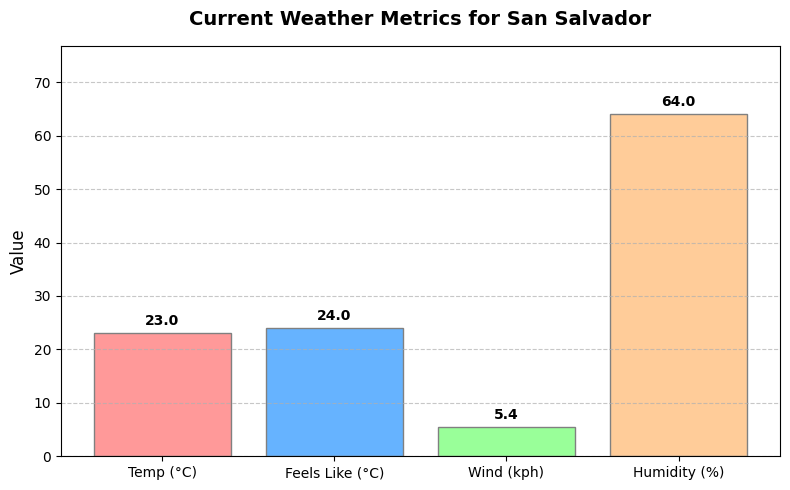

In [10]:
import matplotlib.pyplot as plt

if response.status_code == 200:
    data = response.json()

    loc_name = data["location"]["name"]
    loc_region = data["location"]["region"]
    temp = round(data["current"]["temp_c"])
    feels_like = round(data["current"]["feelslike_c"])
    condition = data["current"]["condition"]["text"]
    wind = data["current"]["wind_kph"]
    humidity = data["current"]["humidity"]

    print("=" * 45)
    print(f" \U0001F324\uFE0F  WEATHER REPORT: {loc_name.upper()}, {loc_region.upper()} ")
    print("=" * 45)
    print(f"  \u2022 Condition     : {condition}")
    print(f"  \u2022 Temperature   : {temp}\u00b0C")
    print(f"  \u2022 Feels Like    : {feels_like}\u00b0C")
    print(f"  \u2022 Wind Speed    : {wind} kph")
    print(f"  \u2022 Humidity      : {humidity}%")
    print("=" * 45)

    metrics = ['Temp (\u00b0C)', 'Feels Like (\u00b0C)', 'Wind (kph)', 'Humidity (%)']
    values = [temp, feels_like, wind, humidity]
    colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

    plt.figure(figsize=(8, 5))
    bars = plt.bar(metrics, values, color=colors, edgecolor='grey', linewidth=1)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 1,
                 f'{height}',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.title(f"Current Weather Metrics for {loc_name}", fontsize=14, fontweight='bold', pad=15)
    plt.ylabel("Value", fontsize=12)
    plt.ylim(0, max(values) * 1.2)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

else:
    print("Error:", response.status_code, response.text)

## Block 6 — Fetch forecast weather (3 days)

In [11]:
BASE_URL = "https://api.weatherapi.com/v1/forecast.json"

params = {
    "key": API_KEY,
    "q": "San Salvador",
    "days": 3
}

response = requests.get(BASE_URL, params=params)

if response.status_code == 200:
    data = response.json()

    print("Location:", data["location"]["name"], data["location"]["region"])
    print("-" * 40)

    for day in data["forecast"]["forecastday"]:
        date = day["date"]
        max_temp = round(day["day"]["maxtemp_c"])
        min_temp = round(day["day"]["mintemp_c"])
        condition = day["day"]["condition"]["text"]

        print(f"{date}: {condition}, High {max_temp}\u00b0C / Low {min_temp}\u00b0C")
else:
    print("Error:", response.status_code, response.text)

Location: San Salvador San Salvador
----------------------------------------
2026-09-19: Light rain shower, High 29°C / Low 20°C
2026-09-20: Light rain shower, High 27°C / Low 18°C
2026-09-21: Light rain shower, High 27°C / Low 19°C


## Block 7 — Inspect the raw forecast JSON

In [12]:
from pprint import pprint
pprint(data)

{'current': {'chance_of_rain': 15,
             'chance_of_snow': 0,
             'cloud': 95,
             'condition': {'code': 1009,
                           'icon': '//cdn.weatherapi.com/weather/64x64/day/122.png',
                           'text': 'Overcast'},
             'dewpoint_c': 15.8,
             'dewpoint_f': 60.5,
             'diff_rad': 128.4,
             'dni': 0.0,
             'feelslike_c': 23.8,
             'feelslike_f': 74.8,
             'gti': 0.0,
             'gust_kph': 7.0,
             'gust_mph': 4.3,
             'heatindex_c': 24.9,
             'heatindex_f': 76.8,
             'humidity': 64,
             'is_day': 1,
             'last_updated': '2026-09-19 09:30',
             'last_updated_epoch': 1789831800,
             'precip_in': 0.0,
             'precip_mm': 0.0,
             'pressure_in': 29.93,
             'pressure_mb': 1014.0,
             'short_rad': 249.24,
             'temp_c': 22.9,
             'temp_f': 73.2,
           

 ## Block 8 — Forecast table + grouped bar chart

Location: San Salvador San Salvador
----------------------------------------

Weather Forecast DataFrame:
      Date  Max Temp (°C)  Min Temp (°C)         Condition  Chance of Rain (%)
2026-09-19             29             20 Light rain shower                  85
2026-09-20             27             18 Light rain shower                  89
2026-09-21             27             19 Light rain shower                  91
----------------------------------------


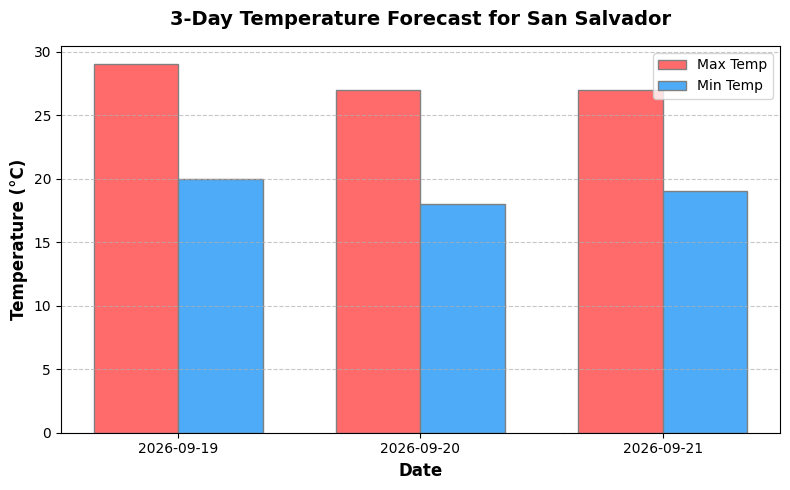

In [13]:
if response.status_code == 200:    data = response.json()    print("Location:", data["location"]["name"], data["location"]["region"])    print("-" * 40)    forecast_list = []    for day in data["forecast"]["forecastday"]:        forecast_list.append({            "Date": day["date"],            "Max Temp (\u00b0C)": round(day["day"]["maxtemp_c"]),            "Min Temp (\u00b0C)": round(day["day"]["mintemp_c"]),            "Condition": day["day"]["condition"]["text"],            "Chance of Rain (%)": day["day"].get("daily_chance_of_rain", 0)        })    df_forecast = pd.DataFrame(forecast_list)    print("\nWeather Forecast DataFrame:")    print(df_forecast.to_string(index=False))    print("-" * 40)    plt.figure(figsize=(8, 5))    x = range(len(df_forecast))    width = 0.35    plt.bar([p - width/2 for p in x], df_forecast["Max Temp (\u00b0C)"], width=width, label="Max Temp", color="#ff6b6b", edgecolor="grey")    plt.bar([p + width/2 for p in x], df_forecast["Min Temp (\u00b0C)"], width=width, label="Min Temp", color="#4dabf7", edgecolor="grey")    plt.xlabel("Date", fontsize=12, fontweight="bold")    plt.ylabel("Temperature (\u00b0C)", fontsize=12, fontweight="bold")    plt.title(f"3-Day Temperature Forecast for {data['location']['name']}", fontsize=14, fontweight="bold", pad=15)    plt.xticks(x, df_forecast["Date"])    plt.legend()    plt.grid(axis="y", linestyle="--", alpha=0.7)    plt.tight_layout()    plt.show()else:    print("Error:", response.status_code, response.text)

# Block 9 — Last 7 days of Rainfall

      Date  Rain (mm)
2026-09-12        3.7
2026-09-13        0.0
2026-09-14        2.5
2026-09-15        6.2
2026-09-16        2.8
2026-09-17       12.7
2026-09-18        2.8


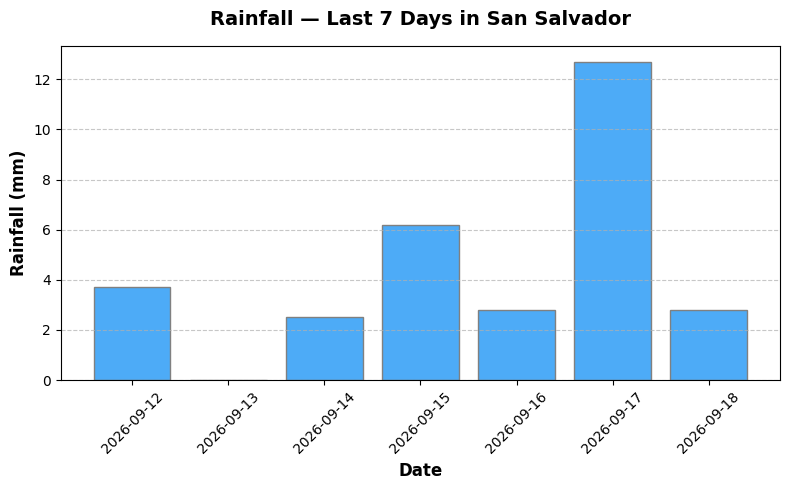

In [14]:
from datetime import date, timedelta

rain_data = []

for i in range(7, 0, -1):
    day = date.today() - timedelta(days=i)
    day_str = day.strftime("%Y-%m-%d")

    response = requests.get(
        "https://api.weatherapi.com/v1/history.json",
        params={"key": API_KEY, "q": "San Salvador", "dt": day_str}
    )

    if response.status_code == 200:
        data = response.json()
        rain_mm = data["forecast"]["forecastday"][0]["day"]["totalprecip_mm"]
        rain_data.append({"Date": day_str, "Rain (mm)": rain_mm})
    else:
        print(f"Error for {day_str}:", response.status_code, response.text)

df_rain = pd.DataFrame(rain_data)
print(df_rain.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.bar(df_rain["Date"], df_rain["Rain (mm)"], color="#4dabf7", edgecolor="grey")

plt.xlabel("Date", fontsize=12, fontweight="bold")
plt.ylabel("Rainfall (mm)", fontsize=12, fontweight="bold")
plt.title("Rainfall — Last 7 Days in San Salvador", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

# Block 10 — Rainfall vs. chance-of-rain trend line (last 7–14 days)

      Date  Rain (mm)  Chance of Rain (%)
2026-09-05        8.2                 100
2026-09-06        1.2                 100
2026-09-07        0.5                 100
2026-09-08        1.3                 100
2026-09-09        0.7                 100
2026-09-10        0.1                 100
2026-09-11       17.6                 100
2026-09-12        3.7                 100
2026-09-13        0.0                   0
2026-09-14        2.5                 100
2026-09-15        6.2                 100
2026-09-16        2.8                 100
2026-09-17       12.7                 100
2026-09-18        2.8                 100


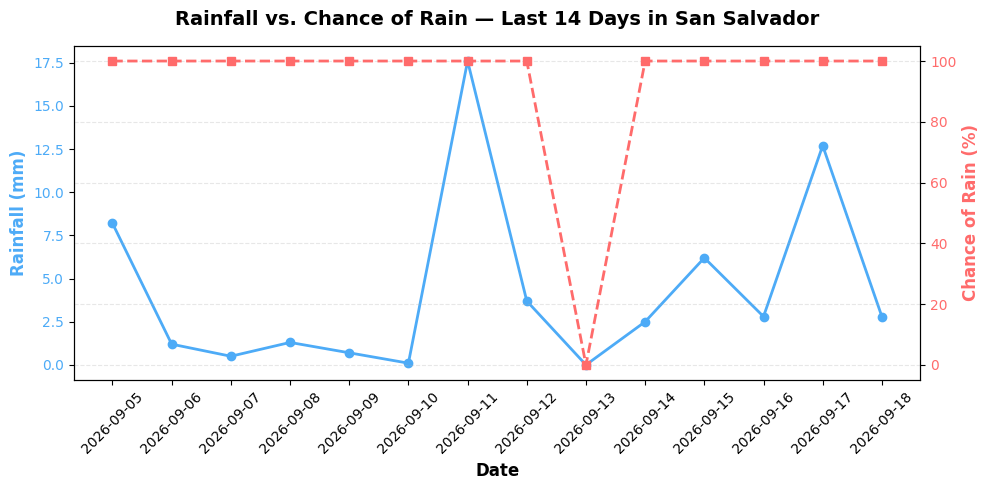

In [20]:
from datetime import date, timedelta

DAYS_BACK = 14
trend_data = []

for i in range(DAYS_BACK, 0, -1):
    day = date.today() - timedelta(days=i)
    day_str = day.strftime("%Y-%m-%d")

    response = requests.get(
        "https://api.weatherapi.com/v1/history.json",
        params={"key": API_KEY, "q": "San Salvador", "dt": day_str}
    )

    if response.status_code == 200:
        data = response.json()
        day_data = data["forecast"]["forecastday"][0]["day"]
        trend_data.append({
            "Date": day_str,
            "Rain (mm)": day_data["totalprecip_mm"],
            "Chance of Rain (%)": day_data.get("daily_chance_of_rain", 0)
        })
    else:
        print(f"Error for {day_str}:", response.status_code, response.text)

df_trend = pd.DataFrame(trend_data)
print(df_trend.to_string(index=False))

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df_trend["Date"], df_trend["Rain (mm)"], color="#4dabf7", marker="o", linewidth=2, label="Rainfall (mm)")
ax1.set_xlabel("Date", fontsize=12, fontweight="bold")
ax1.set_ylabel("Rainfall (mm)", fontsize=12, fontweight="bold", color="#4dabf7")
ax1.tick_params(axis="y", labelcolor="#4dabf7")
ax1.tick_params(axis="x", rotation=45)

ax2 = ax1.twinx()
ax2.plot(df_trend["Date"], df_trend["Chance of Rain (%)"], color="#ff6b6b", marker="s", linewidth=2, linestyle="--", label="Chance of Rain (%)")
ax2.set_ylabel("Chance of Rain (%)", fontsize=12, fontweight="bold", color="#ff6b6b")
ax2.tick_params(axis="y", labelcolor="#ff6b6b")

plt.title(f"Rainfall vs. Chance of Rain — Last {DAYS_BACK} Days in San Salvador", fontsize=14, fontweight="bold", pad=15)
fig.tight_layout()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.show()